In [1]:
!pip install yfinance

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 13.2 MB/s  0:00:00
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   -------------------------------------- - 3.9/4.1 MB 21.0 MB/s eta 0:00:01
   ---------------------------------------- 4.1/4.1 MB 14.3 MB/s  0:00:00

   -------- ------------------------------- 1/5 [peewee]
   -------- ------------------------------- 1/5 [peewee]
   ---------------- ----------------------- 2/5 [lxml]
   ---------------- ----------------------- 2/5 [lxml]
   ---------------- ----------------------- 2/5 [lxml]
   ---------------- ----------------------- 2/5 [lxml]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfinance]
   -------------------------------- ------- 4/5 [yfinance]
   -

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
from pathlib import Path

In [3]:
PROJECT_DIR = Path.cwd().parent

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
TICKERS = ["SPY", "QQQ", "GLD", "TLT", "EEM"]

START_DATE = "2015-01-01"
END_DATE = "2026-01-01"

In [5]:
prices = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)

In [6]:
prices.head()

Price           Close                                                \
Ticker            EEM         GLD        QQQ         SPY        TLT   
Date                                                                  
2015-01-02  30.198088  114.080002  94.561134  169.687851  92.287544   
2015-01-05  29.660645  115.800003  93.174049  166.623322  93.737198   
2015-01-06  29.536022  117.120003  91.924759  165.053879  95.426102   
2015-01-07  30.174728  116.430000  93.109749  167.110657  95.237625   
2015-01-08  30.688803  115.940002  94.891876  170.076080  93.976433   

Price            High                                                ...  \
Ticker            EEM         GLD        QQQ         SPY        TLT  ...   
Date                                                                 ...   
2015-01-02  30.540804  114.800003  95.718571  170.885580  92.533995  ...   
2015-01-05  30.003361  116.000000  94.258003  168.812251  93.961899  ...   
2015-01-06  29.800850  117.500000  93.468015  167.449311  96.034982  ...   
2015-01-07  30.198095  116.879997  93.330212  167.449325  95.658038  ...   
2015-01-08  30.829006  116.870003  95.075594  170.290852  94.498324  ...   

Price            Open                                                  Volume  \
Ticker            EEM         GLD        QQQ         SPY        TLT       EEM   
Date                                                                            
2015-01-02  30.525226  112.489998  95.314390  170.472573  91.540953  65010000   
2015-01-05  30.003361  114.779999  94.147768  168.647051  92.787639  83166600   
2015-01-06  29.668437  116.220001  93.311854  166.928919  94.737499  52066100   
2015-01-07  30.042313  116.470001  92.531031  166.375506  94.737479  64948700   
2015-01-08  30.618701  116.449997  93.899781  168.514916  94.491079  55081600   

Price                                                
Ticker           GLD       QQQ        SPY       TLT  
Date                                                 
2015-01-02   7109600  31314600  121465900   9432000  
2015-01-05   8177400  36521300  169632600   9789500  
2015-01-06  11238300  66205500  209151400  18331300  
2015-01-07   6434200  37577400  125346700   9762900  
2015-01-08   7033700  40212600  147217800   8055300  

[5 rows x 25 columns]

In [7]:
prices.tail()

Price           Close                                                 \
Ticker            EEM         GLD         QQQ         SPY        TLT   
Date                                                                   
2025-12-24  54.138599  411.929993  622.460205  686.730530  85.732704   
2025-12-26  54.516636  416.739990  622.420349  686.660889  85.450279   
2025-12-29  54.377361  398.600006  619.407410  684.213867  85.771660   
2025-12-30  54.596222  398.890015  617.970764  683.378357  85.567154   
2025-12-31  54.427101  396.309998  612.862854  678.315247  84.885422   

Price            High                                                 ...  \
Ticker            EEM         GLD         QQQ         SPY        TLT  ...   
Date                                                                  ...   
2025-12-24  54.178393  412.630005  622.809417  687.178163  85.781402  ...   
2025-12-26  54.536533  418.450012  624.046514  688.003728  85.869058  ...   
2025-12-29  54.397258  403.760010  621.312944  685.556767  85.771660  ...   
2025-12-30  54.705654  403.799988  620.714286  684.920151  85.742457  ...   
2025-12-31  54.636014  400.130005  618.499569  683.726492  85.615849  ...   

Price            Open                                                 \
Ticker            EEM         GLD         QQQ         SPY        TLT   
Date                                                                   
2025-12-24  54.128653  412.250000  620.524773  684.313382  85.469754   
2025-12-26  54.287826  416.480011  623.188494  686.989161  85.800885   
2025-12-29  54.238086  403.660004  618.639204  683.905508  85.654789   
2025-12-30  54.586272  403.600006  618.379832  683.816033  85.450283   
2025-12-31  54.616121  398.600006  618.190301  683.507684  85.391848   

Price         Volume                                          
Ticker           EEM       GLD       QQQ       SPY       TLT  
Date                                                          
2025-12-24   9565300   6718400  18468700  39445600  25942000  
2025-12-26  11352000  10476200  28959800  41613300  26522700  
2025-12-29  18816700  20679200  32458300  62559500  29399800  
2025-12-30  24643000  10179000  31226800  47160700  25106800  
2025-12-31  20000900  10194700  40746500  74144800  36500000  

[5 rows x 25 columns]

In [8]:
prices.shape

(2766, 25)

In [9]:
prices.index.min(), prices.index.max()

(Timestamp('2015-01-02 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [10]:
if isinstance(prices.columns, pd.MultiIndex):
    if "Close" in prices.columns.get_level_values(0):
        prices = prices["Close"]
    elif "Close" in prices.columns.get_level_values(1):
        prices = prices.xs("Close", axis=1, level=1)
else:
    if "Close" in prices.columns:
        prices = prices[["Close"]]

In [11]:
prices.head()

Ticker,EEM,GLD,QQQ,SPY,TLT
Date,,,,,
2015-01-02,30.198088,114.080002,94.561134,169.687851,92.287544
2015-01-05,29.660645,115.800003,93.174049,166.623322,93.737198
2015-01-06,29.536022,117.120003,91.924759,165.053879,95.426102
2015-01-07,30.174728,116.430000,93.109749,167.110657,95.237625
2015-01-08,30.688803,115.940002,94.891876,170.076080,93.976433


In [12]:
prices.index = pd.to_datetime(prices.index)
prices = prices.sort_index()

In [13]:
prices.index.name = "Date"

In [14]:
prices.shape

(2766, 5)

In [15]:
prices.isna().sum()

Ticker
EEM    0
GLD    0
QQQ    0
SPY    0
TLT    0
dtype: int64

In [16]:
prices.index.duplicated().sum()

np.int64(0)

In [17]:
prices.duplicated().sum()

np.int64(0)

In [18]:
prices.dtypes

Ticker
EEM    float64
GLD    float64
QQQ    float64
SPY    float64
TLT    float64
dtype: object

In [19]:
prices.describe()

Ticker,EEM,GLD,QQQ,SPY,TLT
count,2766.000000,2766.000000,2766.000000,2766.000000,2766.000000
mean,37.283981,165.752133,264.254027,336.144656,99.612673
std,6.477575,60.066126,143.998825,139.986241,15.648917
min,22.513224,100.500000,89.375839,154.161621,73.406990
25%,33.257286,120.902502,137.832771,218.351212,88.633732
50%,36.730106,159.375000,241.273857,299.129929,95.009964
75%,40.969010,180.630001,358.920830,420.883301,107.322214
max,54.934235,416.739990,633.456177,686.730530,142.126999


In [20]:
(prices <= 0).sum()

Ticker
EEM    0
GLD    0
QQQ    0
SPY    0
TLT    0
dtype: int64

In [21]:
returns_check = prices.pct_change()

extreme_returns = returns_check[
    (returns_check.abs() > 0.20).any(axis=1)
]

extreme_returns

Ticker,EEM,GLD,QQQ,SPY,TLT
Date,,,,,


In [22]:
raw_file = RAW_DIR / "market_prices_raw.csv"

prices.to_csv(raw_file)

print(f"Saved: {raw_file}")

Saved: C:\Users\dell\Desktop\Market-Risk-Model-Monitoring\data\raw\market_prices_raw.csv


In [23]:
prices_clean = prices.dropna(how="all").copy()

In [24]:
prices_clean.isna().sum()

Ticker
EEM    0
GLD    0
QQQ    0
SPY    0
TLT    0
dtype: int64

In [25]:
processed_file = PROCESSED_DIR / "market_prices_clean.csv"

prices_clean.to_csv(processed_file)

print(f"Saved: {processed_file}")

Saved: C:\Users\dell\Desktop\Market-Risk-Model-Monitoring\data\processed\market_prices_clean.csv


In [26]:
returns = prices.pct_change()

In [27]:
returns = returns.dropna()

In [28]:
returns.shape

(2765, 5)

In [29]:
returns.head()

Ticker,EEM,GLD,QQQ,SPY,TLT
Date,,,,,
2015-01-05,-0.017797,0.015077,-0.014669,-0.018060,0.015708
2015-01-06,-0.004202,0.011399,-0.013408,-0.009419,0.018017
2015-01-07,0.021625,-0.005891,0.012891,0.012461,-0.001975
2015-01-08,0.017037,-0.004209,0.019140,0.017745,-0.013243
2015-01-09,-0.003299,0.011385,-0.006583,-0.008013,0.010953


In [30]:
returns.isna().sum()

Ticker
EEM    0
GLD    0
QQQ    0
SPY    0
TLT    0
dtype: int64

In [31]:
returns.describe()

Ticker,EEM,GLD,QQQ,SPY,TLT
count,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000
mean,0.000296,0.000494,0.000772,0.000564,0.000015
std,0.012865,0.009290,0.013847,0.011208,0.009474
min,-0.124793,-0.064269,-0.119788,-0.109424,-0.066683
25%,-0.006482,-0.004628,-0.005002,-0.003704,-0.005724
50%,0.000708,0.000557,0.001227,0.000637,0.000358
75%,0.007546,0.005414,0.007803,0.005925,0.005593
max,0.080529,0.049038,0.120031,0.105019,0.075196


In [32]:
returns.index.min(), returns.index.max()

(Timestamp('2015-01-05 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [33]:
annualized_volatility = returns.std() * np.sqrt(252)

In [34]:
annualized_volatility

Ticker
EEM    0.204223
GLD    0.147472
QQQ    0.219817
SPY    0.177925
TLT    0.150397
dtype: float64

In [35]:
correlation_matrix = returns.corr()

In [36]:
correlation_matrix

Ticker,EEM,GLD,QQQ,SPY,TLT
Ticker,,,,,
EEM,1.000000,0.166923,0.722496,0.753672,-0.141112
GLD,0.166923,1.000000,0.052230,0.044217,0.280961
QQQ,0.722496,0.052230,1.000000,0.933780,-0.131283
SPY,0.753672,0.044217,0.933780,1.000000,-0.184989
TLT,-0.141112,0.280961,-0.131283,-0.184989,1.000000


In [37]:
weights = pd.Series({
    "EEM": 0.20,
    "GLD": 0.20,
    "QQQ": 0.20,
    "SPY": 0.20,
    "TLT": 0.20
})

In [38]:
weights.sum()

np.float64(1.0)

In [39]:
portfolio_returns = returns.dot(weights)

In [40]:
portfolio_returns.head()

Date
2015-01-05   -0.003948
2015-01-06    0.000478
2015-01-07    0.007822
2015-01-08    0.007294
2015-01-09    0.000888
dtype: float64

In [41]:
portfolio_returns.describe()

count    2765.000000
mean        0.000428
std         0.007556
min        -0.064233
25%        -0.003349
50%         0.000769
75%         0.004294
max         0.067448
dtype: float64

In [42]:
INITIAL_PORTFOLIO_VALUE = 1_000_000

In [43]:
portfolio_pnl = portfolio_returns * INITIAL_PORTFOLIO_VALUE

In [44]:
portfolio_pnl.head()

Date
2015-01-05   -3948.112402
2015-01-06     477.509081
2015-01-07    7822.050592
2015-01-08    7294.164674
2015-01-09     888.491265
dtype: float64

In [45]:
portfolio_annualized_volatility = portfolio_returns.std() * np.sqrt(252)

In [46]:
portfolio_annualized_volatility

np.float64(0.11995125398045241)

In [47]:
portfolio_data = pd.DataFrame({
    "Portfolio_Return": portfolio_returns,
    "Portfolio_PnL": portfolio_pnl
})

In [48]:
portfolio_data.head()

,Portfolio_Return,Portfolio_PnL
Date,,
2015-01-05,-0.003948,-3948.112402
2015-01-06,0.000478,477.509081
2015-01-07,0.007822,7822.050592
2015-01-08,0.007294,7294.164674
2015-01-09,0.000888,888.491265


In [49]:
portfolio_data.isna().sum()

Portfolio_Return    0
Portfolio_PnL       0
dtype: int64

In [50]:
portfolio_data["Portfolio_PnL"].min()

np.float64(-64233.36084953389)

In [51]:
portfolio_data.index.min(), portfolio_data.index.max()

(Timestamp('2015-01-05 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [52]:
portfolio_file = PROCESSED_DIR / "portfolio_returns_pnl.csv"

portfolio_data.to_csv(portfolio_file)

print(f"Saved: {portfolio_file}")

Saved: C:\Users\dell\Desktop\Market-Risk-Model-Monitoring\data\processed\portfolio_returns_pnl.csv


In [53]:
VAR_CONFIDENCE = 0.99

In [54]:
VAR_WINDOW = 250

In [55]:
historical_var_threshold = portfolio_returns.rolling(VAR_WINDOW).quantile(1 - VAR_CONFIDENCE)

In [56]:
historical_var_threshold.tail()

Date
2025-12-24   -0.019532
2025-12-26   -0.019532
2025-12-29   -0.019532
2025-12-30   -0.019532
2025-12-31   -0.019532
dtype: float64

In [57]:
historical_var_threshold = (
    portfolio_returns
    .rolling(VAR_WINDOW)
    .quantile(1 - VAR_CONFIDENCE)
    .shift(1)
)

In [58]:
historical_var = -historical_var_threshold

In [59]:
historical_var.tail()

Date
2025-12-24    0.019532
2025-12-26    0.019532
2025-12-29    0.019532
2025-12-30    0.019532
2025-12-31    0.019532
dtype: float64

In [60]:
historical_var_dollar = historical_var * INITIAL_PORTFOLIO_VALUE

In [61]:
historical_var_dollar.tail()

Date
2025-12-24    19532.416839
2025-12-26    19532.416839
2025-12-29    19532.416839
2025-12-30    19532.416839
2025-12-31    19532.416839
dtype: float64

In [62]:
historical_var_data = pd.DataFrame({
    "Portfolio_Return": portfolio_returns,
    "Historical_VaR": historical_var,
    "Historical_VaR_Dollar": historical_var_dollar
})

In [63]:
historical_var_data["Realized_Loss"] = -historical_var_data["Portfolio_Return"]

In [64]:
historical_var_data["Exception"] = (
    historical_var_data["Realized_Loss"] > historical_var_data["Historical_VaR"]
)

In [65]:
historical_var_data["Exception"].sum()

np.int64(35)

In [66]:
historical_exception_rate = historical_var_data["Exception"].mean()

historical_exception_rate

np.float64(0.012658227848101266)

In [67]:
historical_var_valid = historical_var_data.dropna(subset=["Historical_VaR"]).copy()

In [68]:
historical_var_valid.shape

(2515, 5)

In [69]:
historical_exception_count = historical_var_valid["Exception"].sum()

In [70]:
historical_exception_rate = (
    historical_var_valid["Exception"].mean()
)

In [71]:
historical_exception_count, historical_exception_rate

(np.int64(35), np.float64(0.013916500994035786))

In [72]:
expected_exception_rate = 1 - VAR_CONFIDENCE
expected_exception_count = len(historical_var_valid) * expected_exception_rate

expected_exception_count

25.150000000000023

In [73]:
historical_var_valid["Rolling_Exception_Rate"] = (
    historical_var_valid["Exception"]
    .astype(int)
    .rolling(250)
    .mean()
)

In [74]:
historical_var_valid["Rolling_Exception_Count"] = (
    historical_var_valid["Exception"]
    .astype(int)
    .rolling(250)
    .sum()
)

In [75]:
historical_var_valid["Exception_Severity"] = np.where(
    historical_var_valid["Exception"],
    historical_var_valid["Realized_Loss"] - historical_var_valid["Historical_VaR"],
    0
)

historical_var_valid.loc[
    historical_var_valid["Exception"],
    "Exception_Severity"
].describe()

count    35.000000
mean      0.008123
std       0.009802
min       0.000146
25%       0.001183
50%       0.004410
75%       0.011250
max       0.044870
Name: Exception_Severity, dtype: float64

In [76]:
historical_var_file = PROJECT_DIR / "outputs" / "model_results" / "historical_var_results.csv"

historical_var_valid.to_csv(historical_var_file)

print(f"Saved: {historical_var_file}")

Saved: C:\Users\dell\Desktop\Market-Risk-Model-Monitoring\outputs\model_results\historical_var_results.csv


In [77]:
from scipy.stats import norm

In [78]:
PARAMETRIC_CONFIDENCE = 0.99
PARAMETRIC_WINDOW = 250
Z_SCORE = norm.ppf(PARAMETRIC_CONFIDENCE)

In [79]:
parametric_mean = (
    portfolio_returns
    .rolling(PARAMETRIC_WINDOW)
    .mean()
    .shift(1)
)

In [80]:
parametric_std = (
    portfolio_returns
    .rolling(PARAMETRIC_WINDOW)
    .std()
    .shift(1)
)

In [81]:
parametric_mean.tail(), parametric_std.tail()

(Date
 2025-12-24    0.001021
 2025-12-26    0.001003
 2025-12-29    0.001013
 2025-12-30    0.001007
 2025-12-31    0.001029
 dtype: float64,
 Date
 2025-12-24    0.008142
 2025-12-26    0.008134
 2025-12-29    0.008135
 2025-12-30    0.008143
 2025-12-31    0.008132
 dtype: float64)

In [82]:
parametric_var = -(parametric_mean - Z_SCORE * parametric_std)

In [83]:
parametric_var_dollar = (
    parametric_var * INITIAL_PORTFOLIO_VALUE
)

In [84]:
parametric_var_data = pd.DataFrame({
    "Portfolio_Return": portfolio_returns,
    "Parametric_VaR": parametric_var,
    "Parametric_VaR_Dollar": parametric_var_dollar
})

In [85]:
parametric_var_data["Realized_Loss"] = (
    -parametric_var_data["Portfolio_Return"]
)

In [86]:
parametric_var_data["Exception"] = (
    parametric_var_data["Realized_Loss"]
    > parametric_var_data["Parametric_VaR"]
)

In [87]:
parametric_var_valid = parametric_var_data.dropna(
    subset=["Parametric_VaR"]
).copy()

In [88]:
parametric_var_valid.shape

(2515, 5)

In [89]:
parametric_exception_count = (
    parametric_var_valid["Exception"].sum()
)

In [90]:
parametric_exception_rate = (
    parametric_var_valid["Exception"].mean()
)

In [91]:
parametric_exception_count, parametric_exception_rate

(np.int64(51), np.float64(0.020278330019880716))

In [92]:
parametric_expected_exception_count = (
    len(parametric_var_valid) * (1 - PARAMETRIC_CONFIDENCE)
)

parametric_expected_exception_count

25.150000000000023

In [93]:
parametric_var_valid["Rolling_Exception_Rate"] = (
    parametric_var_valid["Exception"]
    .astype(int)
    .rolling(250)
    .mean()
)

In [94]:
parametric_var_valid["Rolling_Exception_Count"] = (
    parametric_var_valid["Exception"]
    .astype(int)
    .rolling(250)
    .sum()
)

In [95]:
parametric_var_valid["Exception_Severity"] = np.where(
    parametric_var_valid["Exception"],
    parametric_var_valid["Realized_Loss"]
    - parametric_var_valid["Parametric_VaR"],
    0
)

In [96]:
parametric_var_file = (
    PROJECT_DIR
    / "outputs"
    / "model_results"
    / "parametric_var_results.csv"
)

parametric_var_valid.to_csv(parametric_var_file)

print(f"Saved: {parametric_var_file}")

Saved: C:\Users\dell\Desktop\Market-Risk-Model-Monitoring\outputs\model_results\parametric_var_results.csv


In [97]:
EWMA_LAMBDA = 0.94
EWMA_CONFIDENCE = 0.99
EWMA_WINDOW = 250

In [98]:
squared_returns = portfolio_returns.pow(2)

In [99]:
ewma_variance = (
    squared_returns
    .ewm(
        alpha=1 - EWMA_LAMBDA,
        adjust=False,
        min_periods=EWMA_WINDOW
    )
    .mean()
    .shift(1)
)

In [100]:
ewma_volatility = np.sqrt(ewma_variance)

In [101]:
ewma_volatility.tail()

Date
2025-12-24    0.005997
2025-12-26    0.005836
2025-12-29    0.005707
2025-12-30    0.006066
2025-12-31    0.005881
dtype: float64

In [102]:
EWMA_Z_SCORE = norm.ppf(EWMA_CONFIDENCE)

In [103]:
ewma_var = EWMA_Z_SCORE * ewma_volatility

In [104]:
ewma_var_dollar = (
    ewma_var * INITIAL_PORTFOLIO_VALUE
)

In [105]:
ewma_var_data = pd.DataFrame({
    "Portfolio_Return": portfolio_returns,
    "EWMA_VaR": ewma_var,
    "EWMA_VaR_Dollar": ewma_var_dollar
})

In [106]:
ewma_var_data["Realized_Loss"] = (
    -ewma_var_data["Portfolio_Return"]
)

In [107]:
ewma_var_data["Exception"] = (
    ewma_var_data["Realized_Loss"]
    > ewma_var_data["EWMA_VaR"]
)

In [108]:
ewma_var_valid = ewma_var_data.dropna(
    subset=["EWMA_VaR"]
).copy()

In [109]:
ewma_var_valid.shape

(2515, 5)

In [110]:
ewma_exception_count = (
    ewma_var_valid["Exception"].sum()
)

In [111]:
ewma_exception_rate = (
    ewma_var_valid["Exception"].mean()
)

In [112]:
ewma_exception_count, ewma_exception_rate

(np.int64(55), np.float64(0.02186878727634195))

In [113]:
ewma_expected_exception_count = (
    len(ewma_var_valid) * (1 - EWMA_CONFIDENCE)
)

ewma_expected_exception_count

25.150000000000023

In [114]:
ewma_var_valid["Rolling_Exception_Rate"] = (
    ewma_var_valid["Exception"]
    .astype(int)
    .rolling(250)
    .mean()
)

In [115]:
ewma_var_valid["Rolling_Exception_Count"] = (
    ewma_var_valid["Exception"]
    .astype(int)
    .rolling(250)
    .sum()
)

ewma_var_valid["Exception_Severity"] = np.where(
    ewma_var_valid["Exception"],
    ewma_var_valid["Realized_Loss"] - ewma_var_valid["EWMA_VaR"],
    0
)

In [116]:
ewma_var_file = (
    PROJECT_DIR
    / "outputs"
    / "model_results"
    / "ewma_var_results.csv"
)

ewma_var_valid.to_csv(ewma_var_file)

print(f"Saved: {ewma_var_file}")

Saved: C:\Users\dell\Desktop\Market-Risk-Model-Monitoring\outputs\model_results\ewma_var_results.csv


STEP 7

In [117]:
MC_CONFIDENCE = 0.99
MC_WINDOW = 250
MC_SIMULATIONS = 5000

In [118]:
np.random.seed(42)

In [119]:
monte_carlo_var = pd.Series(
    index=portfolio_returns.index,
    dtype=float
)

In [120]:
monte_carlo_mean = pd.Series(
    index=portfolio_returns.index,
    dtype=float
)

In [121]:
monte_carlo_std = pd.Series(
    index=portfolio_returns.index,
    dtype=float
)

In [137]:
for i in range(MC_WINDOW, len(portfolio_returns)):
    historical_window = portfolio_returns.iloc[i-MC_WINDOW:i]

    mu = historical_window.mean()
    sigma = historical_window.std()

    monte_carlo_mean.iloc[i] = mu
    monte_carlo_std.iloc[i] = sigma

    simulated_returns = np.random.normal(
        loc=mu,
        scale=sigma,
        size=MC_SIMULATIONS
    )

    monte_carlo_var.iloc[i] = -np.quantile(
        simulated_returns,
        1 - MC_CONFIDENCE
    )

In [138]:
monte_carlo_var.notna().sum()

np.int64(2515)

In [139]:
monte_carlo_var.tail()

Date
2025-12-24    0.017463
2025-12-26    0.018043
2025-12-29    0.018214
2025-12-30    0.018226
2025-12-31    0.017392
dtype: float64

In [142]:
monte_carlo_var_data = pd.DataFrame({
    "Portfolio_Return": portfolio_returns,
    "Monte_Carlo_VaR": monte_carlo_var
})

In [143]:
monte_carlo_var_data["Monte_Carlo_VaR_Dollar"] = (
    monte_carlo_var_data["Monte_Carlo_VaR"]
    * INITIAL_PORTFOLIO_VALUE
)

In [144]:
monte_carlo_var_data["Realized_Loss"] = (
    -monte_carlo_var_data["Portfolio_Return"]
)

In [145]:
monte_carlo_var_data["Exception"] = (
    monte_carlo_var_data["Realized_Loss"]
    > monte_carlo_var_data["Monte_Carlo_VaR"]
)

In [146]:
monte_carlo_var_valid = monte_carlo_var_data.dropna(
    subset=["Monte_Carlo_VaR"]
).copy()

In [147]:
monte_carlo_observations = len(monte_carlo_var_valid)

monte_carlo_exception_count = (
    monte_carlo_var_valid["Exception"].sum()
)

monte_carlo_observations, monte_carlo_exception_count

(2515, np.int64(50))

monte_carlo_exception_rate = (
    monte_carlo_var_valid["Exception"].mean()
)

monte_carlo_exception_rate

In [149]:
monte_carlo_expected_exception_count = (
    len(monte_carlo_var_valid)
    * (1 - MC_CONFIDENCE)
)

monte_carlo_expected_exception_count

25.150000000000023

In [150]:
monte_carlo_var_valid["Rolling_Exception_Rate"] = (
    monte_carlo_var_valid["Exception"]
    .astype(int)
    .rolling(250)
    .mean()
)

monte_carlo_var_valid["Rolling_Exception_Count"] = (
    monte_carlo_var_valid["Exception"]
    .astype(int)
    .rolling(250)
    .sum()
)

monte_carlo_var_valid["Exception_Severity"] = np.where(
    monte_carlo_var_valid["Exception"],
    monte_carlo_var_valid["Realized_Loss"]
    - monte_carlo_var_valid["Monte_Carlo_VaR"],
    0
)

In [151]:
monte_carlo_var_file = (
    PROJECT_DIR
    / "outputs"
    / "model_results"
    / "monte_carlo_var_results.csv"
)

monte_carlo_var_valid.to_csv(monte_carlo_var_file)

print(f"Saved: {monte_carlo_var_file}")

Saved: C:\Users\dell\Desktop\Market-Risk-Model-Monitoring\outputs\model_results\monte_carlo_var_results.csv


STEP 8

In [153]:
from scipy.stats import chi2

In [154]:
def kupiec_test(exceptions, confidence_level):
    n = len(exceptions)
    x = int(exceptions.sum())
    
    expected_rate = 1 - confidence_level
    actual_rate = x / n
    
    if x == 0:
        log_likelihood_unrestricted = n * np.log(1 - actual_rate)
    elif x == n:
        log_likelihood_unrestricted = n * np.log(actual_rate)
    else:
        log_likelihood_unrestricted = (
            x * np.log(actual_rate)
            + (n - x) * np.log(1 - actual_rate)
        )
    
    log_likelihood_restricted = (
        x * np.log(expected_rate)
        + (n - x) * np.log(1 - expected_rate)
    )
    
    lr_statistic = -2 * (
        log_likelihood_restricted
        - log_likelihood_unrestricted
    )
    
    p_value = 1 - chi2.cdf(lr_statistic, df=1)
    
    return {
        "Observations": n,
        "Exceptions": x,
        "Actual_Exception_Rate": actual_rate,
        "Expected_Exception_Rate": expected_rate,
        "LR_Statistic": lr_statistic,
        "P_Value": p_value
    }

In [155]:
historical_kupiec = kupiec_test(
    historical_var_valid["Exception"],
    VAR_CONFIDENCE
)

historical_kupiec

{'Observations': 2515,
 'Exceptions': 35,
 'Actual_Exception_Rate': 0.013916500994035786,
 'Expected_Exception_Rate': 0.010000000000000009,
 'LR_Statistic': np.float64(3.473330240357768),
 'P_Value': np.float64(0.06236563411125284)}

In [156]:
parametric_kupiec = kupiec_test(
    parametric_var_valid["Exception"],
    PARAMETRIC_CONFIDENCE
)

parametric_kupiec

{'Observations': 2515,
 'Exceptions': 51,
 'Actual_Exception_Rate': 0.020278330019880716,
 'Expected_Exception_Rate': 0.010000000000000009,
 'LR_Statistic': np.float64(20.68002134151527),
 'P_Value': np.float64(5.427940496849359e-06)}

In [157]:
ewma_kupiec = kupiec_test(
    ewma_var_valid["Exception"],
    EWMA_CONFIDENCE
)

ewma_kupiec

{'Observations': 2515,
 'Exceptions': 55,
 'Actual_Exception_Rate': 0.02186878727634195,
 'Expected_Exception_Rate': 0.010000000000000009,
 'LR_Statistic': np.float64(26.731582406205803),
 'P_Value': np.float64(2.3376925528673098e-07)}

In [158]:
monte_carlo_kupiec = kupiec_test(
    monte_carlo_var_valid["Exception"],
    MC_CONFIDENCE
)

monte_carlo_kupiec

{'Observations': 2515,
 'Exceptions': 50,
 'Actual_Exception_Rate': 0.019880715705765408,
 'Expected_Exception_Rate': 0.010000000000000009,
 'LR_Statistic': np.float64(19.265356084749726),
 'P_Value': np.float64(1.1375175352323907e-05)}

In [159]:
kupiec_results = pd.DataFrame({
    "Historical Simulation": historical_kupiec,
    "Parametric": parametric_kupiec,
    "EWMA": ewma_kupiec,
    "Monte Carlo": monte_carlo_kupiec
}).T

In [160]:
kupiec_results

,Observations,Exceptions,Actual_Exception_Rate,Expected_Exception_Rate,LR_Statistic,P_Value
Historical Simulation,2515.0,35.0,0.013917,0.01,3.473330,6.236563e-02
Parametric,2515.0,51.0,0.020278,0.01,20.680021,5.427940e-06
EWMA,2515.0,55.0,0.021869,0.01,26.731582,2.337693e-07
Monte Carlo,2515.0,50.0,0.019881,0.01,19.265356,1.137518e-05


In [161]:
kupiec_results["Decision"] = np.where(
    kupiec_results["P_Value"] >= 0.05,
    "Pass",
    "Reject"
)

In [162]:
kupiec_results[
    [
        "Observations",
        "Exceptions",
        "Actual_Exception_Rate",
        "Expected_Exception_Rate",
        "LR_Statistic",
        "P_Value",
        "Decision"
    ]
]

,Observations,Exceptions,Actual_Exception_Rate,Expected_Exception_Rate,LR_Statistic,P_Value,Decision
Historical Simulation,2515.0,35.0,0.013917,0.01,3.473330,6.236563e-02,Pass
Parametric,2515.0,51.0,0.020278,0.01,20.680021,5.427940e-06,Reject
EWMA,2515.0,55.0,0.021869,0.01,26.731582,2.337693e-07,Reject
Monte Carlo,2515.0,50.0,0.019881,0.01,19.265356,1.137518e-05,Reject


In [163]:
def christoffersen_test(exceptions, confidence_level):
    exceptions = np.asarray(exceptions, dtype=int)

    n00 = np.sum((exceptions[:-1] == 0) & (exceptions[1:] == 0))
    n01 = np.sum((exceptions[:-1] == 0) & (exceptions[1:] == 1))
    n10 = np.sum((exceptions[:-1] == 1) & (exceptions[1:] == 0))
    n11 = np.sum((exceptions[:-1] == 1) & (exceptions[1:] == 1))

    pi0 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    pi1 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)

    eps = 1e-12

    def safe_log(x):
        return np.log(np.clip(x, eps, 1 - eps))

    log_likelihood_independent = (
        (n00 + n10) * safe_log(1 - pi)
        + (n01 + n11) * safe_log(pi)
    )

    log_likelihood_conditional = (
        n00 * safe_log(1 - pi0)
        + n01 * safe_log(pi0)
        + n10 * safe_log(1 - pi1)
        + n11 * safe_log(pi1)
    )

    lr_independence = -2 * (
        log_likelihood_independent
        - log_likelihood_conditional
    )

    p_value_independence = 1 - chi2.cdf(
        lr_independence,
        df=1
    )

    kupiec_result = kupiec_test(
        exceptions,
        confidence_level
    )

    lr_conditional_coverage = (
        kupiec_result["LR_Statistic"]
        + lr_independence
    )

    p_value_conditional_coverage = 1 - chi2.cdf(
        lr_conditional_coverage,
        df=2
    )

    return {
        "N00": n00,
        "N01": n01,
        "N10": n10,
        "N11": n11,
        "LR_Independence": lr_independence,
        "P_Value_Independence": p_value_independence,
        "LR_Conditional_Coverage": lr_conditional_coverage,
        "P_Value_Conditional_Coverage": p_value_conditional_coverage
    }

In [164]:
historical_christoffersen = christoffersen_test(
    historical_var_valid["Exception"],
    VAR_CONFIDENCE
)

historical_christoffersen

{'N00': np.int64(2449),
 'N01': np.int64(30),
 'N10': np.int64(30),
 'N11': np.int64(5),
 'LR_Independence': np.float64(15.501806253219286),
 'P_Value_Independence': np.float64(8.242645286704597e-05),
 'LR_Conditional_Coverage': np.float64(18.975136493577054),
 'P_Value_Conditional_Coverage': np.float64(7.578817752640354e-05)}

In [165]:
parametric_christoffersen = christoffersen_test(
    parametric_var_valid["Exception"],
    PARAMETRIC_CONFIDENCE
)

parametric_christoffersen

{'N00': np.int64(2420),
 'N01': np.int64(43),
 'N10': np.int64(43),
 'N11': np.int64(8),
 'LR_Independence': np.float64(20.855154543580454),
 'P_Value_Independence': np.float64(4.953573818244905e-06),
 'LR_Conditional_Coverage': np.float64(41.535175885095725),
 'P_Value_Conditional_Coverage': np.float64(9.566457626064562e-10)}

In [166]:
ewma_christoffersen = christoffersen_test(
    ewma_var_valid["Exception"],
    EWMA_CONFIDENCE
)

ewma_christoffersen

{'N00': np.int64(2408),
 'N01': np.int64(51),
 'N10': np.int64(51),
 'N11': np.int64(4),
 'LR_Independence': np.float64(4.315804382952024),
 'P_Value_Independence': np.float64(0.03775991497815179),
 'LR_Conditional_Coverage': np.float64(31.047386789157827),
 'P_Value_Conditional_Coverage': np.float64(1.8119475408973074e-07)}

In [167]:
monte_carlo_christoffersen = christoffersen_test(
    monte_carlo_var_valid["Exception"],
    MC_CONFIDENCE
)

monte_carlo_christoffersen

{'N00': np.int64(2421),
 'N01': np.int64(43),
 'N10': np.int64(43),
 'N11': np.int64(7),
 'LR_Independence': np.float64(16.860765257673222),
 'P_Value_Independence': np.float64(4.02245244367494e-05),
 'LR_Conditional_Coverage': np.float64(36.12612134242295),
 'P_Value_Conditional_Coverage': np.float64(1.4299222472757833e-08)}

In [168]:
christoffersen_results = pd.DataFrame({
    "Historical Simulation": historical_christoffersen,
    "Parametric": parametric_christoffersen,
    "EWMA": ewma_christoffersen,
    "Monte Carlo": monte_carlo_christoffersen
}).T

In [169]:
christoffersen_results[
    [
        "N00",
        "N01",
        "N10",
        "N11",
        "LR_Independence",
        "P_Value_Independence"
    ]
]

,N00,N01,N10,N11,LR_Independence,P_Value_Independence
Historical Simulation,2449.0,30.0,30.0,5.0,15.501806,0.000082
Parametric,2420.0,43.0,43.0,8.0,20.855155,0.000005
EWMA,2408.0,51.0,51.0,4.0,4.315804,0.037760
Monte Carlo,2421.0,43.0,43.0,7.0,16.860765,0.000040


In [170]:
christoffersen_results["Independence_Decision"] = np.where(
    christoffersen_results["P_Value_Independence"] >= 0.05,
    "Pass",
    "Reject"
)

In [171]:
christoffersen_results["Conditional_Coverage_Decision"] = np.where(
    christoffersen_results["P_Value_Conditional_Coverage"] >= 0.05,
    "Pass",
    "Reject"
)

In [172]:
christoffersen_results[
    [
        "LR_Independence",
        "P_Value_Independence",
        "Independence_Decision",
        "LR_Conditional_Coverage",
        "P_Value_Conditional_Coverage",
        "Conditional_Coverage_Decision"
    ]
]

,LR_Independence,P_Value_Independence,Independence_Decision,LR_Conditional_Coverage,P_Value_Conditional_Coverage,Conditional_Coverage_Decision
Historical Simulation,15.501806,0.000082,Reject,18.975136,7.578818e-05,Reject
Parametric,20.855155,0.000005,Reject,41.535176,9.566458e-10,Reject
EWMA,4.315804,0.037760,Reject,31.047387,1.811948e-07,Reject
Monte Carlo,16.860765,0.000040,Reject,36.126121,1.429922e-08,Reject


In [173]:
model_comparison = pd.DataFrame(index=[
    "Historical Simulation",
    "Parametric",
    "EWMA",
    "Monte Carlo"
])

In [174]:
model_comparison["Observations"] = kupiec_results["Observations"]
model_comparison["Exceptions"] = kupiec_results["Exceptions"]
model_comparison["Actual_Exception_Rate"] = kupiec_results["Actual_Exception_Rate"]
model_comparison["Expected_Exception_Rate"] = kupiec_results["Expected_Exception_Rate"]

In [175]:
model_comparison["Kupiec_LR"] = kupiec_results["LR_Statistic"]
model_comparison["Kupiec_P_Value"] = kupiec_results["P_Value"]
model_comparison["Kupiec_Decision"] = kupiec_results["Decision"]

In [176]:
model_comparison["Independence_LR"] = christoffersen_results["LR_Independence"]
model_comparison["Independence_P_Value"] = (
    christoffersen_results["P_Value_Independence"]
)
model_comparison["Independence_Decision"] = (
    christoffersen_results["Independence_Decision"]
)

In [177]:
model_comparison["Conditional_Coverage_LR"] = (
    christoffersen_results["LR_Conditional_Coverage"]
)

model_comparison["Conditional_Coverage_P_Value"] = (
    christoffersen_results["P_Value_Conditional_Coverage"]
)

model_comparison["Conditional_Coverage_Decision"] = (
    christoffersen_results["Conditional_Coverage_Decision"]
)

In [178]:
model_comparison

,Observations,Exceptions,Actual_Exception_Rate,Expected_Exception_Rate,Kupiec_LR,Kupiec_P_Value,Kupiec_Decision,Independence_LR,Independence_P_Value,Independence_Decision,Conditional_Coverage_LR,Conditional_Coverage_P_Value,Conditional_Coverage_Decision
Historical Simulation,2515.0,35.0,0.013917,0.01,3.473330,6.236563e-02,Pass,15.501806,0.000082,Reject,18.975136,7.578818e-05,Reject
Parametric,2515.0,51.0,0.020278,0.01,20.680021,5.427940e-06,Reject,20.855155,0.000005,Reject,41.535176,9.566458e-10,Reject
EWMA,2515.0,55.0,0.021869,0.01,26.731582,2.337693e-07,Reject,4.315804,0.037760,Reject,31.047387,1.811948e-07,Reject
Monte Carlo,2515.0,50.0,0.019881,0.01,19.265356,1.137518e-05,Reject,16.860765,0.000040,Reject,36.126121,1.429922e-08,Reject


In [179]:
model_comparison["Overall_Status"] = np.where(
    (
        (model_comparison["Kupiec_Decision"] == "Pass")
        &
        (model_comparison["Independence_Decision"] == "Pass")
        &
        (model_comparison["Conditional_Coverage_Decision"] == "Pass")
    ),
    "Pass",
    "Review"
)

In [180]:
model_comparison[
    [
        "Exceptions",
        "Actual_Exception_Rate",
        "Kupiec_Decision",
        "Independence_Decision",
        "Conditional_Coverage_Decision",
        "Overall_Status"
    ]
]

,Exceptions,Actual_Exception_Rate,Kupiec_Decision,Independence_Decision,Conditional_Coverage_Decision,Overall_Status
Historical Simulation,35.0,0.013917,Pass,Reject,Reject,Review
Parametric,51.0,0.020278,Reject,Reject,Reject,Review
EWMA,55.0,0.021869,Reject,Reject,Reject,Review
Monte Carlo,50.0,0.019881,Reject,Reject,Reject,Review


In [181]:
backtesting_file = (
    PROJECT_DIR
    / "outputs"
    / "model_results"
    / "var_backtesting_comparison.csv"
)

model_comparison.to_csv(backtesting_file)

print(f"Saved: {backtesting_file}")

Saved: C:\Users\dell\Desktop\Market-Risk-Model-Monitoring\outputs\model_results\var_backtesting_comparison.csv


In [182]:
statistical_tests_file = (
    PROJECT_DIR
    / "outputs"
    / "model_results"
    / "statistical_backtesting_results.csv"
)

model_comparison.to_csv(statistical_tests_file)

print(f"Saved: {statistical_tests_file}")

Saved: C:\Users\dell\Desktop\Market-Risk-Model-Monitoring\outputs\model_results\statistical_backtesting_results.csv


STEP 9

In [183]:
validation_data = pd.DataFrame({
    "Portfolio_Return": portfolio_returns,
    "Realized_Loss": -portfolio_returns,
    "Historical_VaR": historical_var,
    "Parametric_VaR": parametric_var,
    "EWMA_VaR": ewma_var,
    "Monte_Carlo_VaR": monte_carlo_var
})

In [184]:
validation_data = validation_data.dropna().copy()

In [185]:
validation_data.shape

(2515, 6)

In [186]:
validation_data["Historical_Exception"] = (
    validation_data["Realized_Loss"]
    > validation_data["Historical_VaR"]
)

In [187]:
validation_data["Parametric_Exception"] = (
    validation_data["Realized_Loss"]
    > validation_data["Parametric_VaR"]
)

In [188]:
validation_data["EWMA_Exception"] = (
    validation_data["Realized_Loss"]
    > validation_data["EWMA_VaR"]
)

In [189]:
validation_data["Monte_Carlo_Exception"] = (
    validation_data["Realized_Loss"]
    > validation_data["Monte_Carlo_VaR"]
)

In [190]:
validation_data["Historical_Rolling_Rate"] = (
    validation_data["Historical_Exception"]
    .astype(int)
    .rolling(250)
    .mean()
)

In [191]:
validation_data["Parametric_Rolling_Rate"] = (
    validation_data["Parametric_Exception"]
    .astype(int)
    .rolling(250)
    .mean()
)

In [192]:
validation_data["EWMA_Rolling_Rate"] = (
    validation_data["EWMA_Exception"]
    .astype(int)
    .rolling(250)
    .mean()
)

validation_data["Monte_Carlo_Rolling_Rate"] = (
    validation_data["Monte_Carlo_Exception"]
    .astype(int)
    .rolling(250)
    .mean()
)

In [193]:
average_var = validation_data[
    [
        "Historical_VaR",
        "Parametric_VaR",
        "EWMA_VaR",
        "Monte_Carlo_VaR"
    ]
].mean()

average_var

Historical_VaR     0.019751
Parametric_VaR     0.016689
EWMA_VaR           0.016168
Monte_Carlo_VaR    0.016657
dtype: float64

In [194]:
minimum_var = validation_data[
    [
        "Historical_VaR",
        "Parametric_VaR",
        "EWMA_VaR",
        "Monte_Carlo_VaR"
    ]
].min()

minimum_var

Historical_VaR     0.008978
Parametric_VaR     0.007596
EWMA_VaR           0.006124
Monte_Carlo_VaR    0.007410
dtype: float64

In [195]:
maximum_var = validation_data[
    [
        "Historical_VaR",
        "Parametric_VaR",
        "EWMA_VaR",
        "Monte_Carlo_VaR"
    ]
].max()

maximum_var

Historical_VaR     0.043197
Parametric_VaR     0.028329
EWMA_VaR           0.067016
Monte_Carlo_VaR    0.029219
dtype: float64

In [196]:
average_realized_loss = validation_data["Realized_Loss"].mean()

average_realized_loss

np.float64(-0.0004795337076164607)

In [197]:
exception_counts = pd.Series({
    "Historical Simulation": validation_data["Historical_Exception"].sum(),
    "Parametric": validation_data["Parametric_Exception"].sum(),
    "EWMA": validation_data["EWMA_Exception"].sum(),
    "Monte Carlo": validation_data["Monte_Carlo_Exception"].sum()
})

exception_counts

Historical Simulation    35
Parametric               51
EWMA                     55
Monte Carlo              50
dtype: int64

In [198]:
exception_rates = exception_counts / len(validation_data)

exception_rates

Historical Simulation    0.013917
Parametric               0.020278
EWMA                     0.021869
Monte Carlo              0.019881
dtype: float64

In [199]:
average_exception_severity = pd.Series({
    "Historical Simulation": (
        validation_data.loc[
            validation_data["Historical_Exception"],
            "Realized_Loss"
        ]
        - validation_data.loc[
            validation_data["Historical_Exception"],
            "Historical_VaR"
        ]
    ).mean(),
    
    "Parametric": (
        validation_data.loc[
            validation_data["Parametric_Exception"],
            "Realized_Loss"
        ]
        - validation_data.loc[
            validation_data["Parametric_Exception"],
            "Parametric_VaR"
        ]
    ).mean(),
    
    "EWMA": (
        validation_data.loc[
            validation_data["EWMA_Exception"],
            "Realized_Loss"
        ]
        - validation_data.loc[
            validation_data["EWMA_Exception"],
            "EWMA_VaR"
        ]
    ).mean(),
    
    "Monte Carlo": (
        validation_data.loc[
            validation_data["Monte_Carlo_Exception"],
            "Realized_Loss"
        ]
        - validation_data.loc[
            validation_data["Monte_Carlo_Exception"],
            "Monte_Carlo_VaR"
        ]
    ).mean()
})

average_exception_severity

Historical Simulation    0.008123
Parametric               0.007625
EWMA                     0.004743
Monte Carlo              0.007770
dtype: float64

In [200]:
rolling_validation = validation_data[
    [
        "Historical_Rolling_Rate",
        "Parametric_Rolling_Rate",
        "EWMA_Rolling_Rate",
        "Monte_Carlo_Rolling_Rate"
    ]
].tail(1)

rolling_validation

,Historical_Rolling_Rate,Parametric_Rolling_Rate,EWMA_Rolling_Rate,Monte_Carlo_Rolling_Rate
Date,,,,
2025-12-31,0.016,0.024,0.02,0.02


In [203]:
validation_summary = pd.DataFrame({
    "Average_VaR": [
        average_var["Historical_VaR"],
        average_var["Parametric_VaR"],
        average_var["EWMA_VaR"],
        average_var["Monte_Carlo_VaR"]
    ],
    "Minimum_VaR": [
        minimum_var["Historical_VaR"],
        minimum_var["Parametric_VaR"],
        minimum_var["EWMA_VaR"],
        minimum_var["Monte_Carlo_VaR"]
    ],
    "Maximum_VaR": [
        maximum_var["Historical_VaR"],
        maximum_var["Parametric_VaR"],
        maximum_var["EWMA_VaR"],
        maximum_var["Monte_Carlo_VaR"]
    ],
    "Exception_Count": [
        exception_counts["Historical Simulation"],
        exception_counts["Parametric"],
        exception_counts["EWMA"],
        exception_counts["Monte Carlo"]
    ],
    "Exception_Rate": [
        exception_rates["Historical Simulation"],
        exception_rates["Parametric"],
        exception_rates["EWMA"],
        exception_rates["Monte Carlo"]
    ],
    "Average_Exception_Severity": [
        average_exception_severity["Historical Simulation"],
        average_exception_severity["Parametric"],
        average_exception_severity["EWMA"],
        average_exception_severity["Monte Carlo"]
    ]
}, index=[
    "Historical Simulation",
    "Parametric",
    "EWMA",
    "Monte Carlo"
])

validation_summary

,Average_VaR,Minimum_VaR,Maximum_VaR,Exception_Count,Exception_Rate,Average_Exception_Severity
Historical Simulation,0.019751,0.008978,0.043197,35,0.013917,0.008123
Parametric,0.016689,0.007596,0.028329,51,0.020278,0.007625
EWMA,0.016168,0.006124,0.067016,55,0.021869,0.004743
Monte Carlo,0.016657,0.007410,0.029219,50,0.019881,0.007770


In [204]:
validation_file = (
    PROJECT_DIR
    / "outputs"
    / "model_results"
    / "rolling_validation_summary.csv"
)

validation_summary.to_csv(validation_file)

print(f"Saved: {validation_file}")

Saved: C:\Users\dell\Desktop\Market-Risk-Model-Monitoring\outputs\model_results\rolling_validation_summary.csv


STEP 10

In [205]:
import matplotlib.pyplot as plt

In [206]:
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

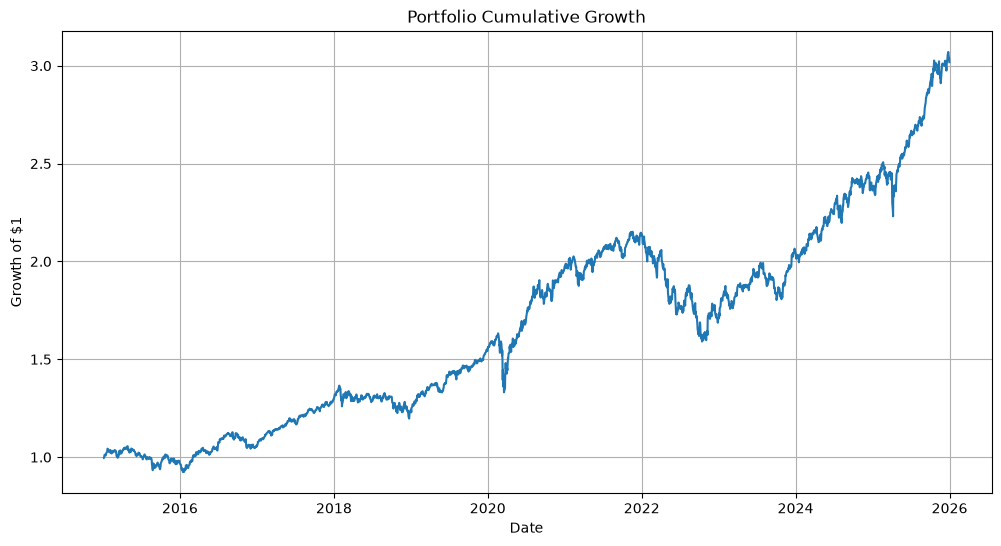

In [207]:
portfolio_cumulative = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(portfolio_cumulative.index, portfolio_cumulative)
plt.title("Portfolio Cumulative Growth")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

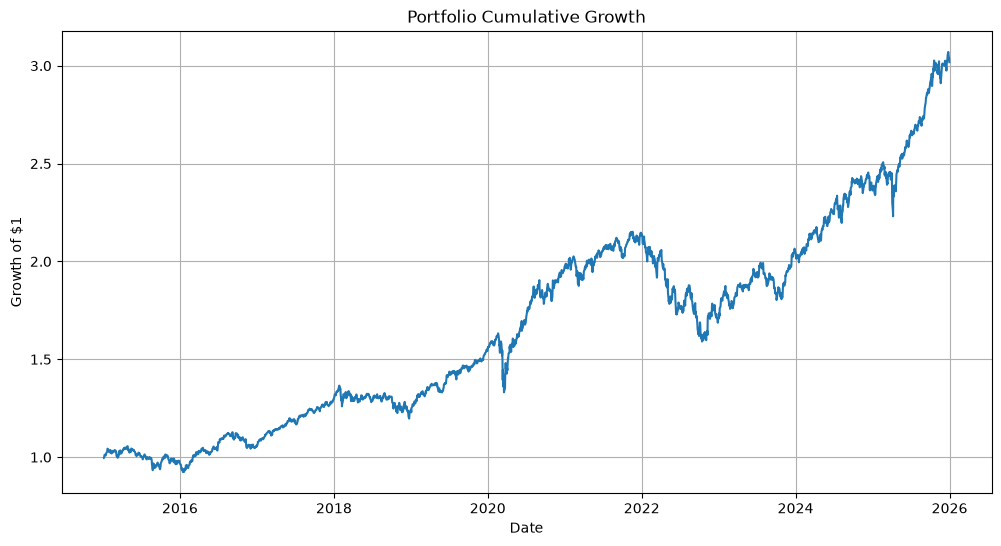

In [208]:
plt.figure(figsize=(12, 6))
plt.plot(portfolio_cumulative.index, portfolio_cumulative)
plt.title("Portfolio Cumulative Growth")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.savefig(
    FIGURES_DIR / "portfolio_cumulative_growth.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

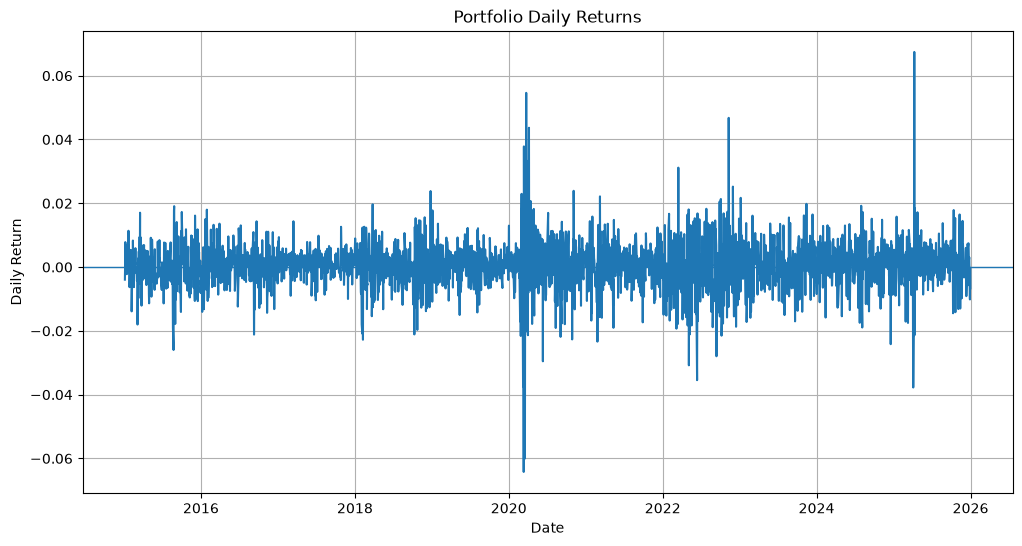

In [209]:
plt.figure(figsize=(12, 6))
plt.plot(portfolio_returns.index, portfolio_returns)
plt.axhline(0, linewidth=1)
plt.title("Portfolio Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

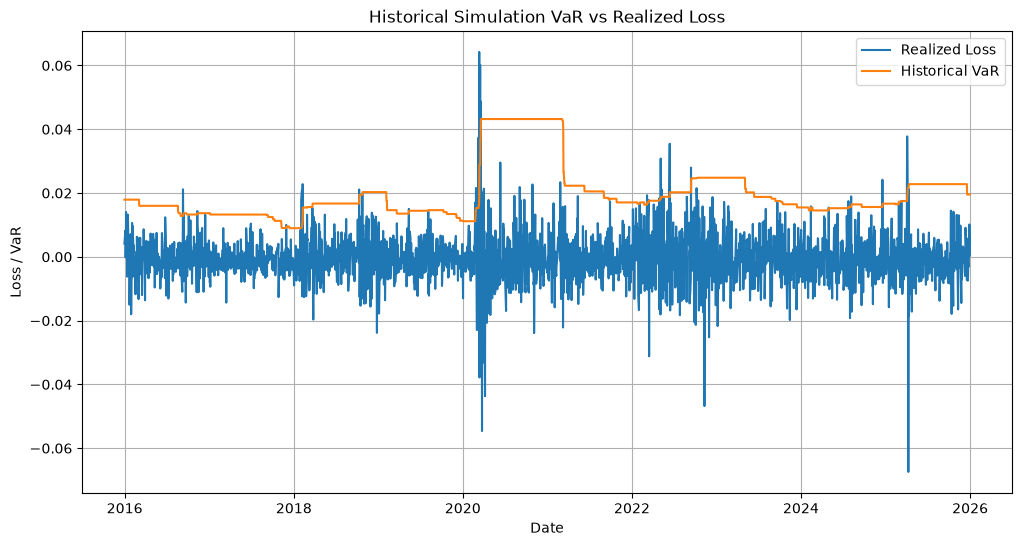

In [210]:
plt.figure(figsize=(12, 6))
plt.plot(
    historical_var_valid.index,
    historical_var_valid["Realized_Loss"],
    label="Realized Loss"
)
plt.plot(
    historical_var_valid.index,
    historical_var_valid["Historical_VaR"],
    label="Historical VaR"
)
plt.title("Historical Simulation VaR vs Realized Loss")
plt.xlabel("Date")
plt.ylabel("Loss / VaR")
plt.legend()
plt.grid(True)
plt.show()

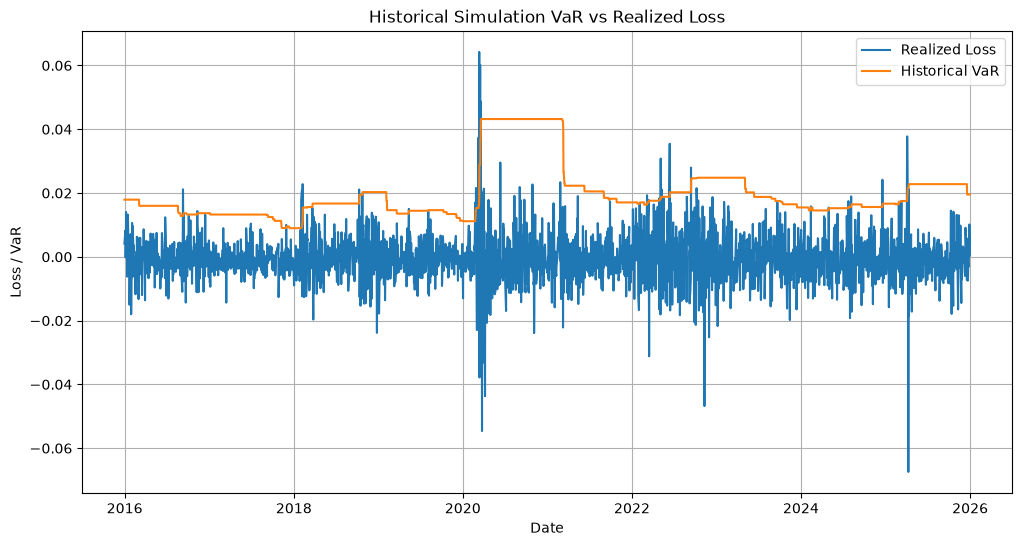

In [211]:
plt.figure(figsize=(12, 6))
plt.plot(
    historical_var_valid.index,
    historical_var_valid["Realized_Loss"],
    label="Realized Loss"
)
plt.plot(
    historical_var_valid.index,
    historical_var_valid["Historical_VaR"],
    label="Historical VaR"
)
plt.title("Historical Simulation VaR vs Realized Loss")
plt.xlabel("Date")
plt.ylabel("Loss / VaR")
plt.legend()
plt.grid(True)
plt.savefig(
    FIGURES_DIR / "historical_var_monitoring.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

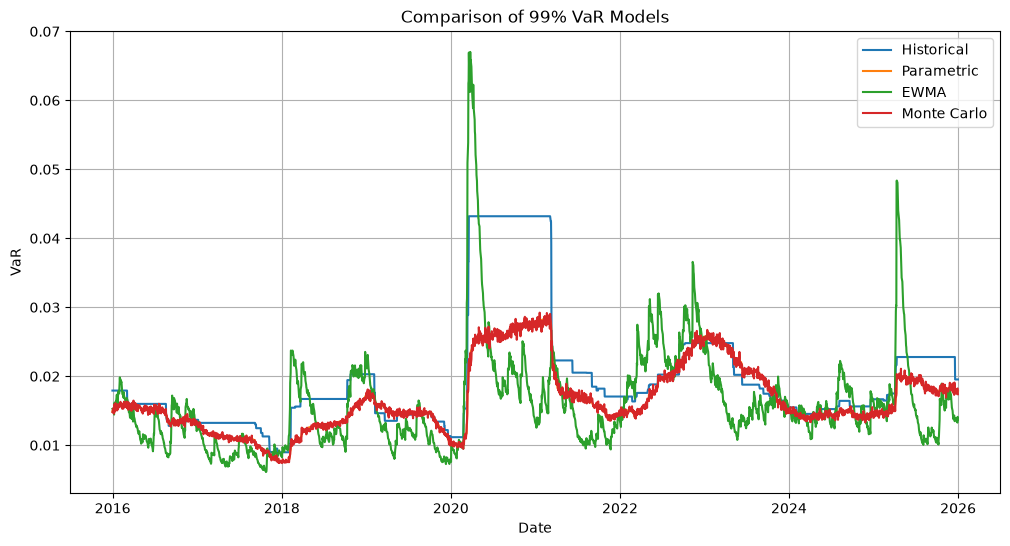

In [212]:
plt.figure(figsize=(12, 6))

plt.plot(
    validation_data.index,
    validation_data["Historical_VaR"],
    label="Historical"
)

plt.plot(
    validation_data.index,
    validation_data["Parametric_VaR"],
    label="Parametric"
)

plt.plot(
    validation_data.index,
    validation_data["EWMA_VaR"],
    label="EWMA"
)

plt.plot(
    validation_data.index,
    validation_data["Monte_Carlo_VaR"],
    label="Monte Carlo"
)

plt.title("Comparison of 99% VaR Models")
plt.xlabel("Date")
plt.ylabel("VaR")
plt.legend()
plt.grid(True)
plt.show()

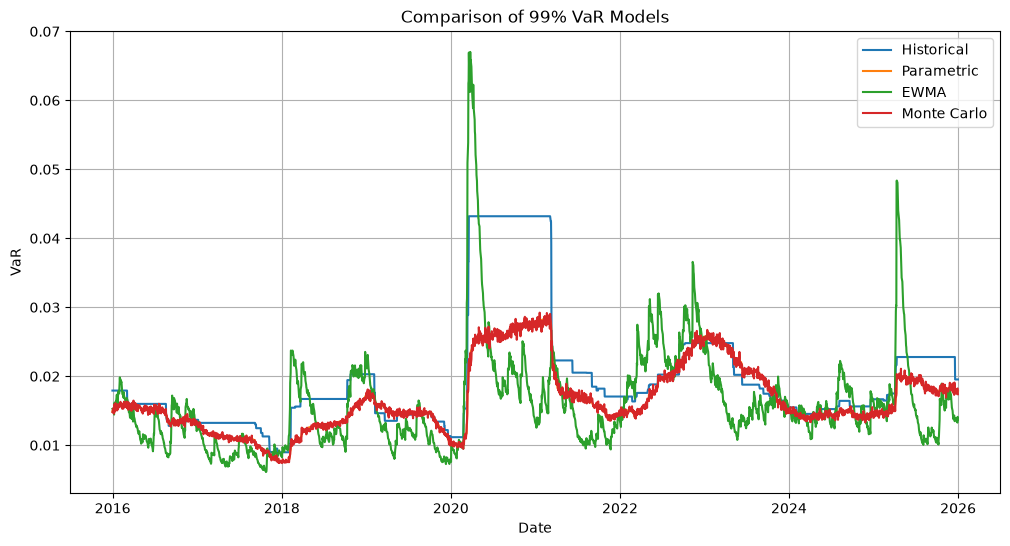

In [213]:
plt.figure(figsize=(12, 6))

plt.plot(
    validation_data.index,
    validation_data["Historical_VaR"],
    label="Historical"
)

plt.plot(
    validation_data.index,
    validation_data["Parametric_VaR"],
    label="Parametric"
)

plt.plot(
    validation_data.index,
    validation_data["EWMA_VaR"],
    label="EWMA"
)

plt.plot(
    validation_data.index,
    validation_data["Monte_Carlo_VaR"],
    label="Monte Carlo"
)

plt.title("Comparison of 99% VaR Models")
plt.xlabel("Date")
plt.ylabel("VaR")
plt.legend()
plt.grid(True)

plt.savefig(
    FIGURES_DIR / "var_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

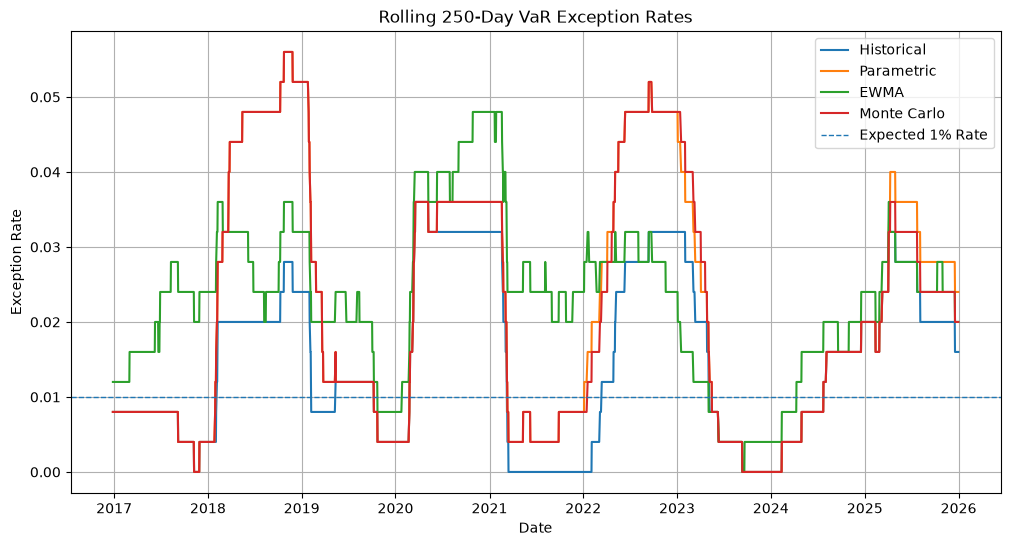

In [214]:
plt.figure(figsize=(12, 6))

plt.plot(
    validation_data.index,
    validation_data["Historical_Rolling_Rate"],
    label="Historical"
)

plt.plot(
    validation_data.index,
    validation_data["Parametric_Rolling_Rate"],
    label="Parametric"
)

plt.plot(
    validation_data.index,
    validation_data["EWMA_Rolling_Rate"],
    label="EWMA"
)

plt.plot(
    validation_data.index,
    validation_data["Monte_Carlo_Rolling_Rate"],
    label="Monte Carlo"
)

plt.axhline(
    0.01,
    linestyle="--",
    linewidth=1,
    label="Expected 1% Rate"
)

plt.title("Rolling 250-Day VaR Exception Rates")
plt.xlabel("Date")
plt.ylabel("Exception Rate")
plt.legend()
plt.grid(True)
plt.show()

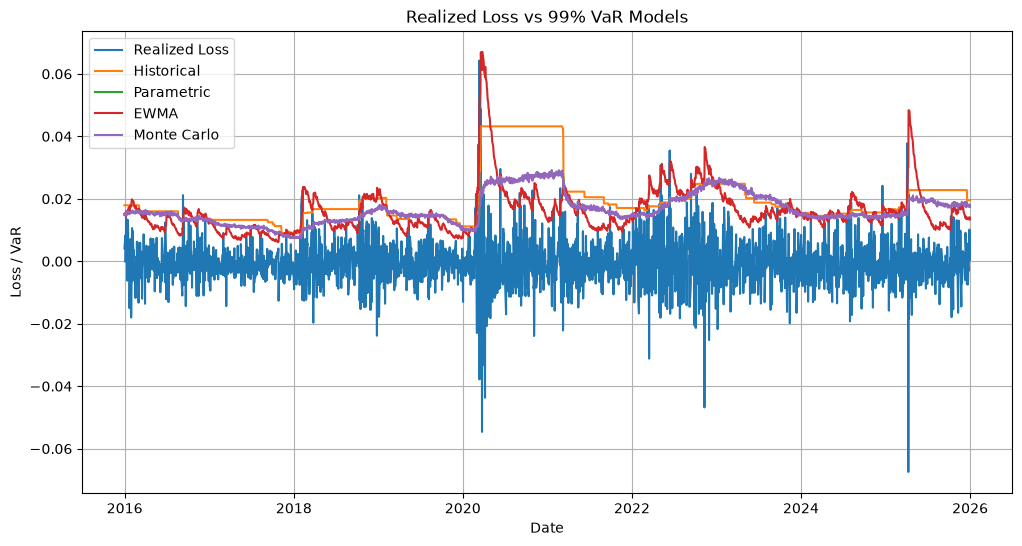

In [215]:
plt.figure(figsize=(12, 6))

plt.plot(
    validation_data.index,
    validation_data["Realized_Loss"],
    label="Realized Loss"
)

plt.plot(
    validation_data.index,
    validation_data["Historical_VaR"],
    label="Historical"
)

plt.plot(
    validation_data.index,
    validation_data["Parametric_VaR"],
    label="Parametric"
)

plt.plot(
    validation_data.index,
    validation_data["EWMA_VaR"],
    label="EWMA"
)

plt.plot(
    validation_data.index,
    validation_data["Monte_Carlo_VaR"],
    label="Monte Carlo"
)

plt.title("Realized Loss vs 99% VaR Models")
plt.xlabel("Date")
plt.ylabel("Loss / VaR")
plt.legend()
plt.grid(True)
plt.show()

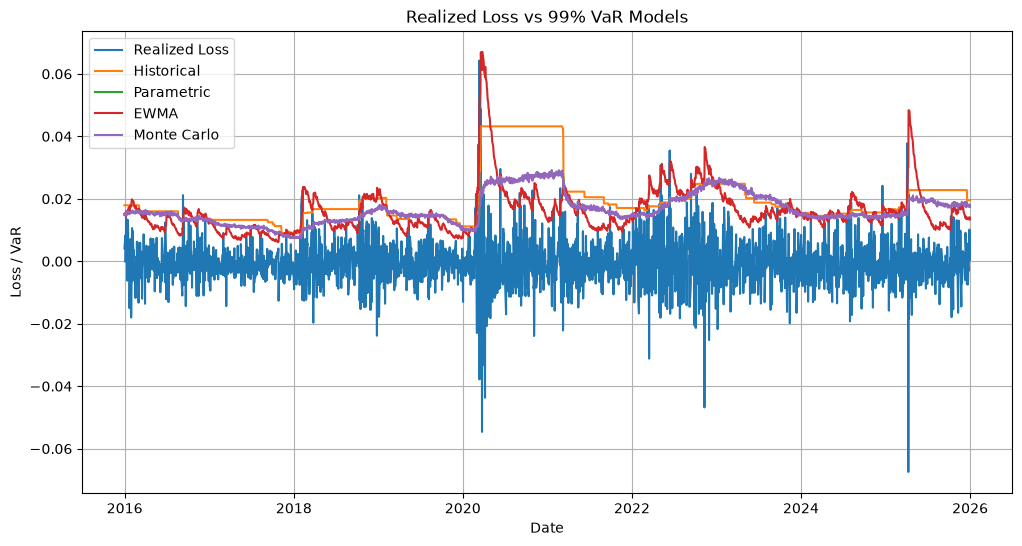

In [216]:
plt.figure(figsize=(12, 6))

plt.plot(
    validation_data.index,
    validation_data["Realized_Loss"],
    label="Realized Loss"
)

plt.plot(
    validation_data.index,
    validation_data["Historical_VaR"],
    label="Historical"
)

plt.plot(
    validation_data.index,
    validation_data["Parametric_VaR"],
    label="Parametric"
)

plt.plot(
    validation_data.index,
    validation_data["EWMA_VaR"],
    label="EWMA"
)

plt.plot(
    validation_data.index,
    validation_data["Monte_Carlo_VaR"],
    label="Monte Carlo"
)

plt.title("Realized Loss vs 99% VaR Models")
plt.xlabel("Date")
plt.ylabel("Loss / VaR")
plt.legend()
plt.grid(True)

plt.savefig(
    FIGURES_DIR / "realized_loss_vs_var.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

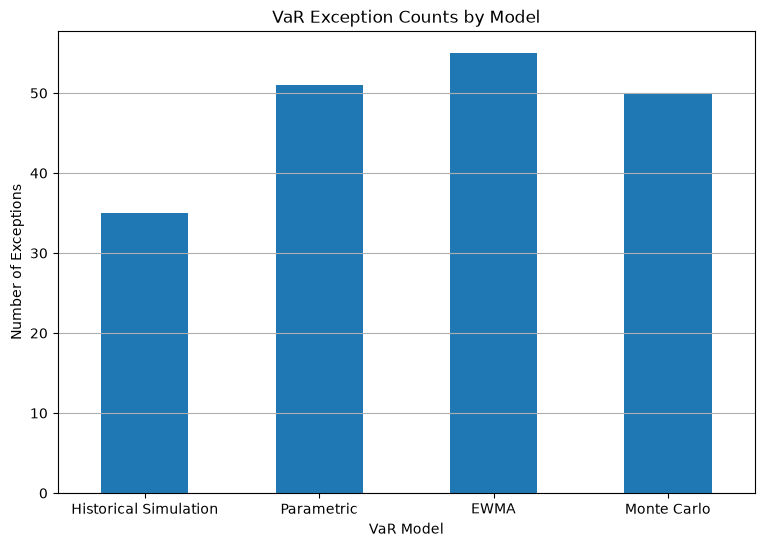

In [217]:
plt.figure(figsize=(9, 6))

exception_counts.plot(kind="bar")

plt.title("VaR Exception Counts by Model")
plt.xlabel("VaR Model")
plt.ylabel("Number of Exceptions")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

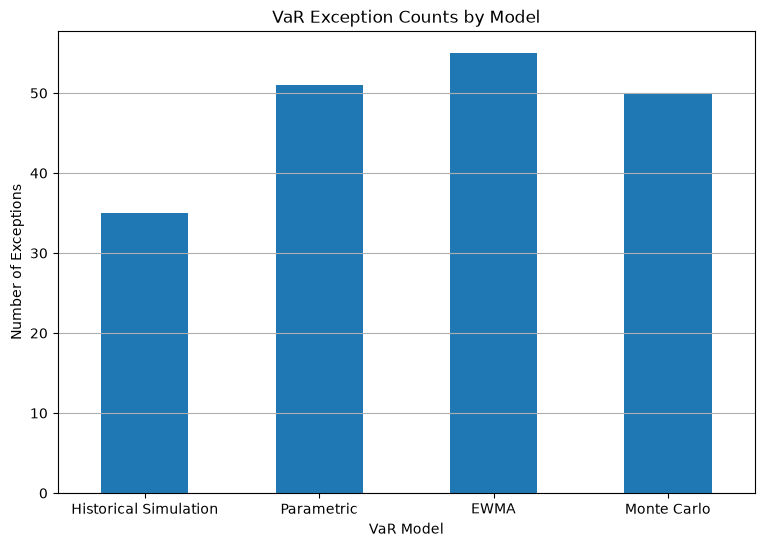

In [218]:
plt.figure(figsize=(9, 6))

exception_counts.plot(kind="bar")

plt.title("VaR Exception Counts by Model")
plt.xlabel("VaR Model")
plt.ylabel("Number of Exceptions")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.savefig(
    FIGURES_DIR / "var_exception_counts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

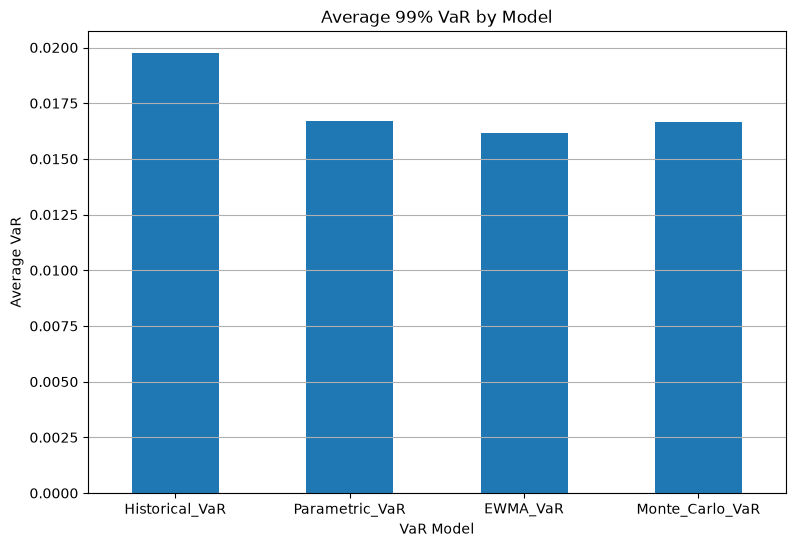

In [219]:
plt.figure(figsize=(9, 6))

average_var.plot(kind="bar")

plt.title("Average 99% VaR by Model")
plt.xlabel("VaR Model")
plt.ylabel("Average VaR")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

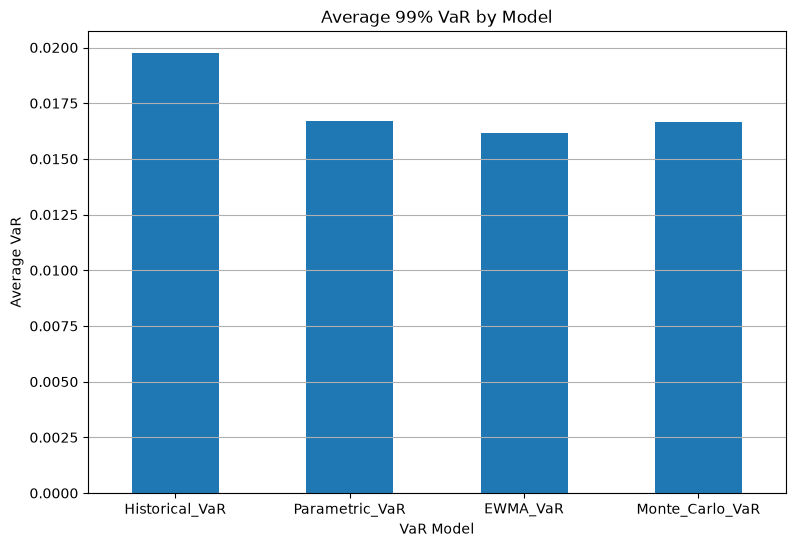

In [220]:
plt.figure(figsize=(9, 6))

average_var.plot(kind="bar")

plt.title("Average 99% VaR by Model")
plt.xlabel("VaR Model")
plt.ylabel("Average VaR")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.savefig(
    FIGURES_DIR / "average_var_by_model.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

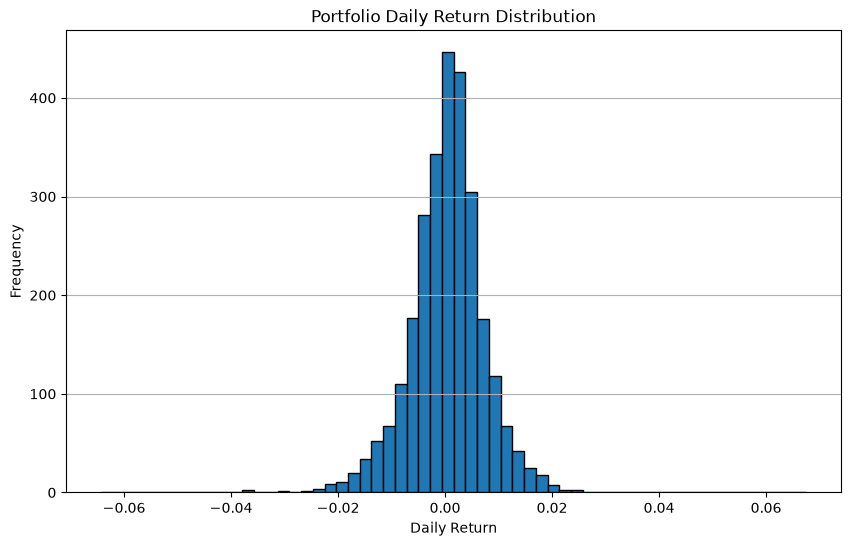

In [221]:
plt.figure(figsize=(10, 6))

plt.hist(
    portfolio_returns,
    bins=60,
    edgecolor="black"
)

plt.title("Portfolio Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.show()

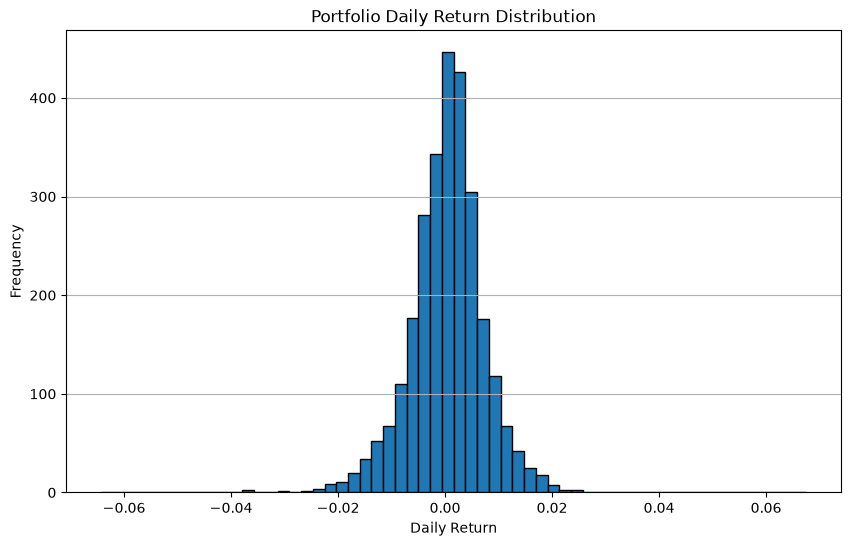

In [222]:
plt.figure(figsize=(10, 6))

plt.hist(
    portfolio_returns,
    bins=60,
    edgecolor="black"
)

plt.title("Portfolio Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(axis="y")

plt.savefig(
    FIGURES_DIR / "portfolio_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [223]:
model_monitoring_summary = validation_summary.copy()

model_monitoring_summary["Expected_Exception_Count"] = (
    len(validation_data) * 0.01
)

model_monitoring_summary["Exception_Deviation"] = (
    model_monitoring_summary["Exception_Count"]
    - model_monitoring_summary["Expected_Exception_Count"]
)

model_monitoring_summary

,Average_VaR,Minimum_VaR,Maximum_VaR,Exception_Count,Exception_Rate,Average_Exception_Severity,Expected_Exception_Count,Exception_Deviation
Historical Simulation,0.019751,0.008978,0.043197,35,0.013917,0.008123,25.15,9.85
Parametric,0.016689,0.007596,0.028329,51,0.020278,0.007625,25.15,25.85
EWMA,0.016168,0.006124,0.067016,55,0.021869,0.004743,25.15,29.85
Monte Carlo,0.016657,0.007410,0.029219,50,0.019881,0.007770,25.15,24.85


In [224]:
monitoring_file = (
    PROJECT_DIR
    / "outputs"
    / "model_results"
    / "final_model_monitoring_summary.csv"
)

model_monitoring_summary.to_csv(monitoring_file)

print(f"Saved: {monitoring_file}")

Saved: C:\Users\dell\Desktop\Market-Risk-Model-Monitoring\outputs\model_results\final_model_monitoring_summary.csv


STEP 11


In [225]:
rolling_volatility = (
    portfolio_returns
    .rolling(30)
    .std()
    * np.sqrt(252)
)

rolling_volatility.tail()

Date
2025-12-24    0.095081
2025-12-26    0.094948
2025-12-29    0.091717
2025-12-30    0.090454
2025-12-31    0.089612
dtype: float64

In [226]:
long_run_volatility = portfolio_returns.std() * np.sqrt(252)

long_run_volatility

np.float64(0.11995125398045241)

In [227]:
volatility_threshold = rolling_volatility.quantile(0.90)

volatility_threshold

np.float64(0.15784070866633143)

In [228]:
high_volatility_flag = (
    rolling_volatility >= volatility_threshold
)

high_volatility_flag.sum()

np.int64(274)

In [229]:
portfolio_growth = (1 + portfolio_returns).cumprod()

running_peak = portfolio_growth.cummax()

drawdown = (
    portfolio_growth / running_peak
) - 1

In [230]:
stress_drawdown_flag = drawdown <= -0.10

stress_drawdown_flag.sum()

np.int64(423)

In [231]:
worst_days = (
    portfolio_returns
    .nsmallest(10)
    .to_frame("Portfolio_Return")
)

worst_days

,Portfolio_Return
Date,
2020-03-12,-0.064233
2020-03-16,-0.060137
2020-03-18,-0.048750
2025-04-04,-0.037755
2020-03-09,-0.037417
2020-03-11,-0.035848
2022-06-13,-0.035453
2022-05-05,-0.030803
2020-06-11,-0.029542


In [232]:
highest_volatility_days = (
    rolling_volatility
    .dropna()
    .nlargest(10)
    .to_frame("Annualized_30D_Volatility")
)

highest_volatility_days

,Annualized_30D_Volatility
Date,
2020-04-06,0.464362
2020-04-08,0.463454
2020-04-07,0.462446
2020-04-09,0.459860
2020-04-13,0.459701
2020-04-15,0.459161
2020-04-14,0.458783
2020-04-16,0.456491
2020-04-20,0.456469


In [238]:
stress_analysis = pd.DataFrame({
    "Portfolio_Return": portfolio_returns,
    "Realized_Loss": -portfolio_returns,
    
    "Historical_VaR": historical_var,
    "Parametric_VaR": parametric_var,
    "EWMA_VaR": ewma_var,
    "Monte_Carlo_VaR": monte_carlo_var,
    
    "Rolling_30D_Volatility": rolling_volatility,
    "Drawdown": drawdown,
    "High_Volatility": high_volatility_flag,
    "Stress_Drawdown": stress_drawdown_flag
})

stress_analysis = stress_analysis.dropna(
    subset=[
        "Realized_Loss",
        "Historical_VaR",
        "Parametric_VaR",
        "EWMA_VaR",
        "Monte_Carlo_VaR"
    ]
).copy()

In [239]:
stress_analysis.tail()

,Portfolio_Return,Realized_Loss,Historical_VaR,Parametric_VaR,EWMA_VaR,Monte_Carlo_VaR,Rolling_30D_Volatility,Drawdown,High_Volatility,Stress_Drawdown
Date,,,,,,,,,,
2025-12-24,0.002078,-0.002078,0.019532,0.017920,0.013950,0.017463,0.095081,0.000000,False,False
2025-12-26,0.003040,-0.003040,0.019532,0.017920,0.013577,0.018043,0.094948,0.000000,False,False
2025-12-29,-0.010145,0.010145,0.019532,0.017912,0.013277,0.018214,0.091717,-0.010145,False,False
2025-12-30,-0.000234,0.000234,0.019532,0.017935,0.014111,0.018226,0.090454,-0.010377,False,False
2025-12-31,-0.006641,0.006641,0.019532,0.017890,0.013682,0.017392,0.089612,-0.016950,False,False


In [240]:
stress_analysis["Stress_Period"] = (
    stress_analysis["High_Volatility"]
    | stress_analysis["Stress_Drawdown"]
)

stress_analysis["Stress_Period"].sum()

np.int64(532)

In [241]:
stress_period_data = stress_analysis[
    stress_analysis["Stress_Period"]
].copy()

stress_period_data.shape

(532, 11)

In [242]:
stress_exception_counts = pd.Series({
    "Historical Simulation": (
        stress_period_data["Realized_Loss"]
        > stress_period_data["Historical_VaR"]
    ).sum(),
    
    "Parametric": (
        stress_period_data["Realized_Loss"]
        > stress_period_data["Parametric_VaR"]
    ).sum(),
    
    "EWMA": (
        stress_period_data["Realized_Loss"]
        > stress_period_data["EWMA_VaR"]
    ).sum(),
    
    "Monte Carlo": (
        stress_period_data["Realized_Loss"]
        > stress_period_data["Monte_Carlo_VaR"]
    ).sum()
})

stress_exception_counts

Historical Simulation    12
Parametric               17
EWMA                      9
Monte Carlo              17
dtype: int64

In [243]:
stress_exception_rates = (
    stress_exception_counts
    / len(stress_period_data)
)

stress_exception_rates

Historical Simulation    0.022556
Parametric               0.031955
EWMA                     0.016917
Monte Carlo              0.031955
dtype: float64

In [244]:
stress_average_var = stress_period_data[
    [
        "Historical_VaR",
        "Parametric_VaR",
        "EWMA_VaR",
        "Monte_Carlo_VaR"
    ]
].mean()

stress_average_var

Historical_VaR     0.022881
Parametric_VaR     0.020777
EWMA_VaR           0.024408
Monte_Carlo_VaR    0.020727
dtype: float64

In [245]:
stress_average_loss = (
    stress_period_data["Realized_Loss"].mean()
)

stress_average_loss

np.float64(-8.354790039947837e-05)

In [246]:
stress_model_comparison = pd.DataFrame({
    "Stress_Exception_Count": stress_exception_counts.values,
    "Stress_Exception_Rate": stress_exception_rates.values,
    "Stress_Average_VaR": [
        stress_average_var["Historical_VaR"],
        stress_average_var["Parametric_VaR"],
        stress_average_var["EWMA_VaR"],
        stress_average_var["Monte_Carlo_VaR"]
    ]
}, index=[
    "Historical Simulation",
    "Parametric",
    "EWMA",
    "Monte Carlo"
])

stress_model_comparison

,Stress_Exception_Count,Stress_Exception_Rate,Stress_Average_VaR
Historical Simulation,12,0.022556,0.022881
Parametric,17,0.031955,0.020777
EWMA,9,0.016917,0.024408
Monte Carlo,17,0.031955,0.020727


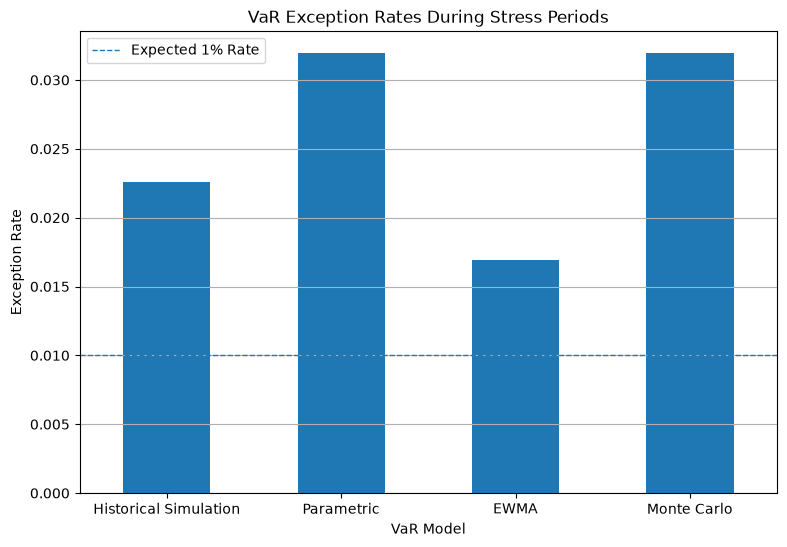

In [247]:
plt.figure(figsize=(9, 6))

stress_exception_rates.plot(kind="bar")

plt.axhline(
    0.01,
    linestyle="--",
    linewidth=1,
    label="Expected 1% Rate"
)

plt.title("VaR Exception Rates During Stress Periods")
plt.xlabel("VaR Model")
plt.ylabel("Exception Rate")
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y")
plt.show()

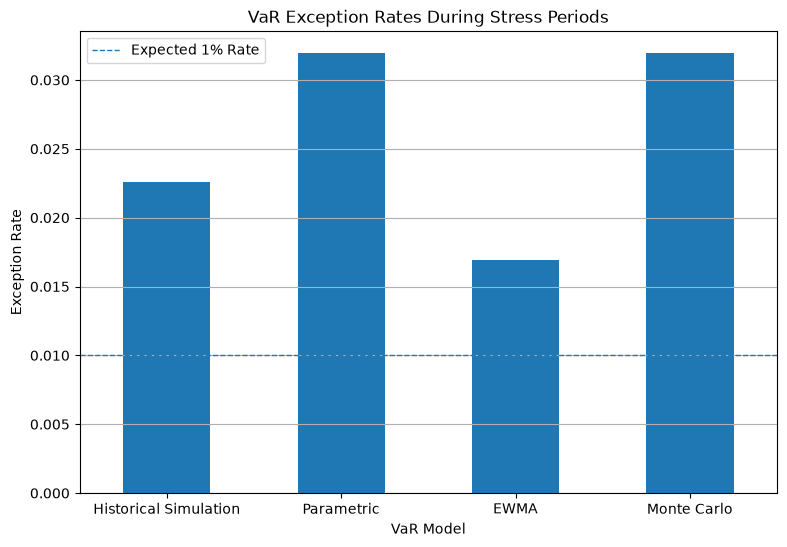

Saved: C:\Users\dell\Desktop\Market-Risk-Model-Monitoring\outputs\model_results\stress_period_analysis.csv


In [248]:
stress_results_file = (
    PROJECT_DIR
    / "outputs"
    / "model_results"
    / "stress_period_analysis.csv"
)

stress_model_comparison.to_csv(stress_results_file)

plt.figure(figsize=(9, 6))

stress_exception_rates.plot(kind="bar")

plt.axhline(
    0.01,
    linestyle="--",
    linewidth=1,
    label="Expected 1% Rate"
)

plt.title("VaR Exception Rates During Stress Periods")
plt.xlabel("VaR Model")
plt.ylabel("Exception Rate")
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y")

plt.savefig(
    FIGURES_DIR / "stress_period_exception_rates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {stress_results_file}")

In [249]:
stress_dataset_file = (
    PROJECT_DIR
    / "outputs"
    / "model_results"
    / "stress_analysis_dataset.csv"
)

stress_analysis.to_csv(stress_dataset_file)

print(f"Saved: {stress_dataset_file}")

Saved: C:\Users\dell\Desktop\Market-Risk-Model-Monitoring\outputs\model_results\stress_analysis_dataset.csv
